# Retail Data Wrangling and Analytics

In [1]:
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import seaborn as sns

# Load Data from PSQL into DataFrame

**Setup Docker Containers**

![](https://i.imgur.com/VQrBVBk.jpg)

```
#make sure you have both Jupyter and PSQL docker container running
docker ps

#Attach a bridge network to both containers so they can communicate with each other
docker network create jarvis-net
#this command works on running containers
docker network connect jarvis-net jarvis-jupyter
docker network connect jarvis-net jarvis-psql

#verify both containers are attached to the jarvis-net
docker network inspect trading-net

#Note: instead of using `localhost`, you should use container names as hostnames.
```

**Data Preperation**

- Use [pandas.read_sql](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.read_sql.html) api to load the PSQL retail table into a Pandas DataFrame

![](https://i.imgur.com/AmkAP63.jpg)

- Get familair with the transaction date with `df.head()`, `df.sample(10)`, `df.info()`, `df.describe()`, etc..



In [2]:
# url = "https://raw.githubusercontent.com/jarviscanada/jarvis_data_eng_demo/feature/data/python_data_wrangling/data/online_retail_II.csv"
# df = pd.read_csv(url)
# df.rename(columns={
#     'Invoice': 'invoice_no',
#     'StockCode': 'stock_code',
#     'Description': 'description',
#     'Quantity': 'quantity',
#     'InvoiceDate': 'invoice_date',
#     'Price': 'unit_price',
#     'Customer ID': 'customer_id',
#     'Country': 'country'
# }, inplace=True)

In [ ]:
!pip3 install psycopg2-binary
conn = psycopg2.connect(
    host="jrvs-psql",  
    port=5432,
    user="postgres",
    password="password",
    database="postgres"
)
df = pd.read_sql("SELECT * FROM retail;", conn)

In [3]:
df['total_amount'] = df['quantity'] * df['unit_price']

In [4]:
df.head()

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country,total_amount
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [5]:
# Invoice number to check in the invoices number since we have C489449
invoice_to_check = '489449'
invoice_to_check in df['invoice_no'].values

False

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 9 columns):
 #   Column        Non-Null Count    Dtype  
---  ------        --------------    -----  
 0   invoice_no    1067371 non-null  object 
 1   stock_code    1067371 non-null  object 
 2   description   1062989 non-null  object 
 3   quantity      1067371 non-null  int64  
 4   invoice_date  1067371 non-null  object 
 5   unit_price    1067371 non-null  float64
 6   customer_id   824364 non-null   float64
 7   country       1067371 non-null  object 
 8   total_amount  1067371 non-null  float64
dtypes: float64(3), int64(1), object(5)
memory usage: 73.3+ MB


In [7]:
df.describe()

,quantity,unit_price,customer_id,total_amount
count,1.067371e+06,1.067371e+06,824364.000000,1.067371e+06
mean,9.938898e+00,4.649388e+00,15324.638504,1.806987e+01
std,1.727058e+02,1.235531e+02,1697.464450,2.924202e+02
min,-8.099500e+04,-5.359436e+04,12346.000000,-1.684696e+05
25%,1.000000e+00,1.250000e+00,13975.000000,3.750000e+00
50%,3.000000e+00,2.100000e+00,15255.000000,9.900000e+00
75%,1.000000e+01,4.150000e+00,16797.000000,1.770000e+01
max,8.099500e+04,3.897000e+04,18287.000000,1.684696e+05


In [8]:
#postiive data frame (placed)
pdf = df[df['total_amount'] >= 0].copy()

# negative data frame (cancelled)
ndf = df[df['total_amount'] < 0].copy()

In [9]:
len(pdf[pdf['total_amount'] >= 0])

1047873

In [10]:
len(ndf[ndf['total_amount'] < 0])

19498

In [11]:
len(pdf[pdf['total_amount'] >= 0]) + len(ndf[ndf['total_amount'] < 0]) - len(df)

0

In [12]:
df[df['total_amount'] == 0]


,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country,total_amount
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.0,NaN,United Kingdom,-0.0
283,489463,71477,short,-240,2009-12-01 10:52:00,0.0,NaN,United Kingdom,-0.0
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.0,NaN,United Kingdom,-0.0
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.0,NaN,United Kingdom,-0.0
3114,489655,20683,NaN,-44,2009-12-01 17:26:00,0.0,NaN,United Kingdom,-0.0
...,...,...,...,...,...,...,...,...,...
1062442,581234,72817,NaN,27,2011-12-08 10:33:00,0.0,NaN,United Kingdom,0.0
1063965,581406,46000M,POLYESTER FILLER PAD 45x45cm,240,2011-12-08 13:58:00,0.0,NaN,United Kingdom,0.0
1063966,581406,46000S,POLYESTER FILLER PAD 40x40cm,300,2011-12-08 13:58:00,0.0,NaN,United Kingdom,0.0
1064015,581408,85175,NaN,20,2011-12-08 14:06:00,0.0,NaN,United Kingdom,0.0


In [13]:
df[df['total_amount'] < 0]


,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country,total_amount
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia,-35.40
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia,-9.90
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia,-17.00
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia,-12.60
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia,-35.40
...,...,...,...,...,...,...,...,...,...
1065910,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,14397.0,United Kingdom,-9.13
1067002,C581499,M,Manual,-1,2011-12-09 10:28:00,224.69,15498.0,United Kingdom,-224.69
1067176,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,15311.0,United Kingdom,-54.75
1067177,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315.0,United Kingdom,-1.25


# Total Invoice Amount Distribution

In [14]:
#Q1 Total amount per invoice

In [15]:
#full placed invoices
full_invoice = pdf.groupby('invoice_no')['total_amount'].sum().reset_index()
#.reset_index() makes the output to look like a table
full_invoice.rename(columns={'total_amount': 'invoice_total'}, inplace=True)

In [16]:
full_invoice.head(15)

,invoice_no,invoice_total
0,489434,505.30
1,489435,145.80
2,489436,630.33
3,489437,310.75
4,489438,2286.24
5,489439,426.30
6,489440,50.40
7,489441,344.34
8,489442,382.37
9,489443,285.06


In [17]:
#full placed invoices
full_pinvoice = pdf.groupby('invoice_no')['total_amount'].sum().reset_index()
#.reset_index() makes the output to look like a table
full_pinvoice.rename(columns={'total_amount': 'invoice_total'}, inplace=True)

In [18]:
full_pinvoice.head(15)

,invoice_no,invoice_total
0,489434,505.30
1,489435,145.80
2,489436,630.33
3,489437,310.75
4,489438,2286.24
5,489439,426.30
6,489440,50.40
7,489441,344.34
8,489442,382.37
9,489443,285.06


In [19]:
#full cancelled invoices
full_ninvoice = ndf.groupby('invoice_no')['total_amount'].sum().reset_index()
#.reset_index() makes the output to look like a table
full_ninvoice.rename(columns={'total_amount': 'invoice_total'}, inplace=True)

In [20]:
full_ninvoice

,invoice_no,invoice_total
0,A506401,-53594.36
1,A516228,-44031.79
2,A528059,-38925.87
3,A563186,-11062.06
4,A563187,-11062.06
...,...,...
8291,C581484,-168469.60
8292,C581490,-32.53
8293,C581499,-224.69
8294,C581568,-54.75


In [21]:
#Q2 hist and box plot including outliers

In [22]:
min_val = full_invoice['invoice_total'].min()
max_val = full_invoice['invoice_total'].max()
median_val = full_invoice['invoice_total'].median()
mean_val = full_invoice['invoice_total'].mean()
mode_val = full_invoice['invoice_total'].mode()[0]

print(f"Min: {min_val}")
print(f"Max: {max_val}")
print(f"Median: {median_val}")
print(f"Mean: {mean_val}")
print(f"Mode: {mode_val}")

Min: 0.0
Max: 168469.6
Median: 263.595
Mean: 462.65261047383746
Mode: 0.0


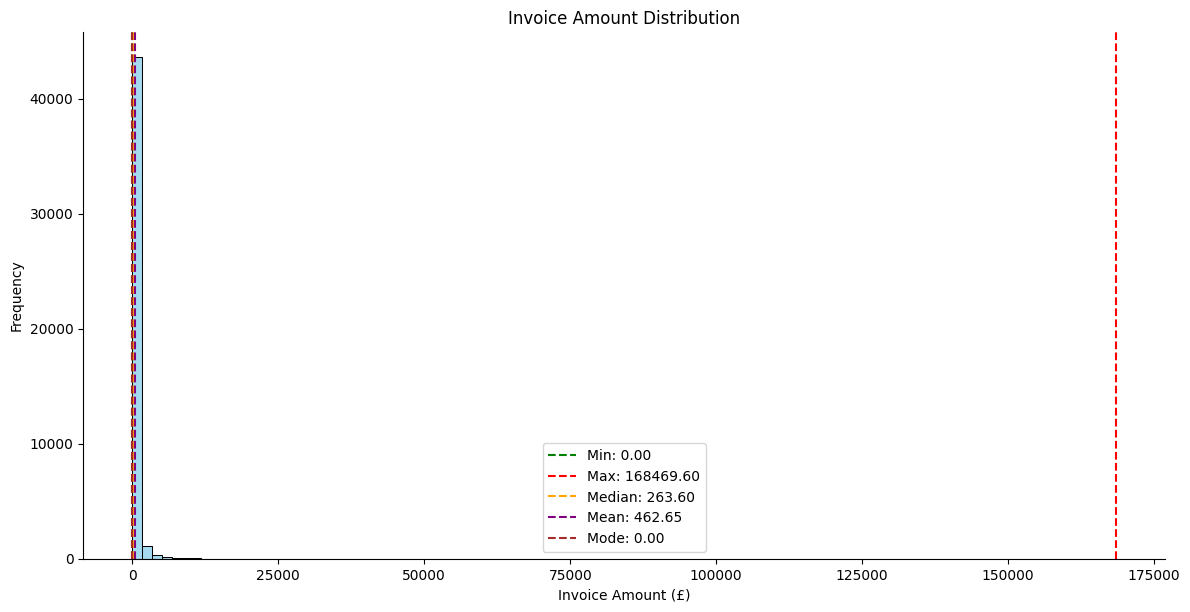

In [23]:
sns.displot(full_invoice, x='invoice_total', bins=100, height=6, aspect=2, color='skyblue')

plt.axvline(min_val, color='green', linestyle='--', label=f'Min: {min_val:.2f}')
plt.axvline(max_val, color='red', linestyle='--', label=f'Max: {max_val:.2f}')
plt.axvline(median_val, color='orange', linestyle='--', label=f'Median: {median_val:.2f}')
plt.axvline(mean_val, color='purple', linestyle='--', label=f'Mean: {mean_val:.2f}')
plt.axvline(mode_val, color='brown', linestyle='--', label=f'Mode: {mode_val:.2f}')

plt.xlabel('Invoice Amount (£)')
plt.ylabel('Frequency')
plt.title('Invoice Amount Distribution')
plt.legend()
plt.show()

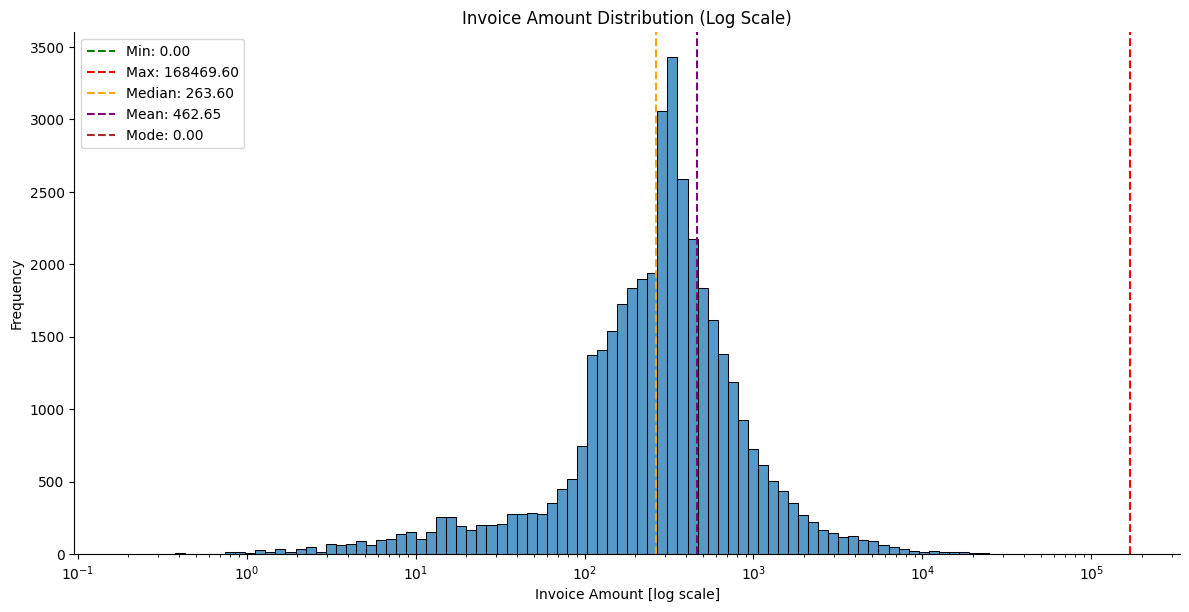

In [24]:
#the normal distribution is clearer when the graph is log scaled

sns.displot(full_invoice, x='invoice_total', bins=100, height=6, aspect=2, log_scale=True)

plt.axvline(min_val, color='green', linestyle='--', label=f'Min: {min_val:.2f}')
plt.axvline(max_val, color='red', linestyle='--', label=f'Max: {max_val:.2f}')
plt.axvline(median_val, color='orange', linestyle='--', label=f'Median: {median_val:.2f}')
plt.axvline(mean_val, color='purple', linestyle='--', label=f'Mean: {mean_val:.2f}')
plt.axvline(mode_val, color='brown', linestyle='--', label=f'Mode: {mode_val:.2f}')

plt.xlabel('Invoice Amount [log scale]')
plt.ylabel('Frequency')
plt.title('Invoice Amount Distribution (Log Scale)')
plt.legend()
plt.show()

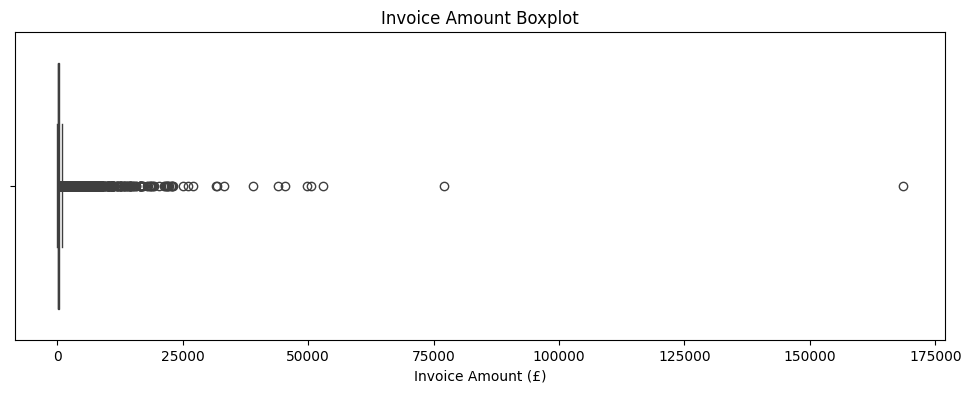

In [25]:
#Box blot
plt.figure(figsize=(12,4))
sns.boxplot(x=full_invoice['invoice_total'])
plt.title('Invoice Amount Boxplot')
plt.xlabel('Invoice Amount (£)')
plt.show()

In [26]:
#Q3 Draw the distribution for the first 85 quantiles of the invoice amount data with min, max, median, mod, and mean.

In [27]:
q85 = full_invoice['invoice_total'].quantile(0.85)
invoice_85 = full_invoice[full_invoice['invoice_total'] <= q85].copy()

In [28]:
min_val = invoice_85['invoice_total'].min()
max_val = invoice_85['invoice_total'].max()
median_val = invoice_85['invoice_total'].median()
mean_val = invoice_85['invoice_total'].mean()
mode_val = invoice_85['invoice_total'].mode()[0]

print(f"Min: {min_val}, Max: {max_val}, Median: {median_val}, Mean: {mean_val}, Mode: {mode_val}")

Min: 0.0, Max: 662.4, Median: 206.72, Mean: 226.05019461241014, Mode: 0.0


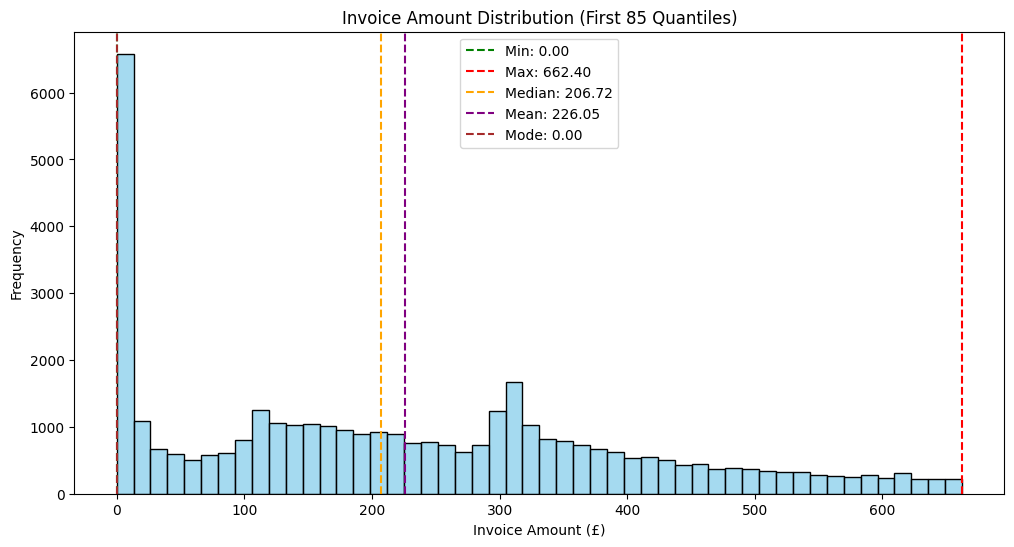

In [29]:
plt.figure(figsize=(12,6))
sns.histplot(invoice_85['invoice_total'], bins=50, color='skyblue')

# Overlay statistics
plt.axvline(min_val, color='green', linestyle='--', label=f'Min: {min_val:.2f}')
plt.axvline(max_val, color='red', linestyle='--', label=f'Max: {max_val:.2f}')
plt.axvline(median_val, color='orange', linestyle='--', label=f'Median: {median_val:.2f}')
plt.axvline(mean_val, color='purple', linestyle='--', label=f'Mean: {mean_val:.2f}')
plt.axvline(mode_val, color='brown', linestyle='--', label=f'Mode: {mode_val:.2f}')

plt.title('Invoice Amount Distribution (First 85 Quantiles)')
plt.xlabel('Invoice Amount (£)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

# Monthly Placed and Canceled Orders

In [30]:
df['invoice_date'] = pd.to_datetime(df['invoice_date'], errors='coerce')
pdf['invoice_date'] = pd.to_datetime(pdf['invoice_date'], errors='coerce')
ndf['invoice_date'] = pd.to_datetime(ndf['invoice_date'], errors='coerce')

In [31]:
df['year_month'] = df['invoice_date'].dt.year * 100 + df['invoice_date'].dt.month
pdf['year_month'] = pdf['invoice_date'].dt.year * 100 + pdf['invoice_date'].dt.month
ndf['year_month'] = ndf['invoice_date'].dt.year * 100 + ndf['invoice_date'].dt.month

In [32]:
total_orders_month = pdf.groupby('year_month')['invoice_no'].nunique().reset_index()
total_orders_month.rename(columns={'invoice_no': 'total_orders'}, inplace=True)

canceled_orders_month = ndf.groupby('year_month')['invoice_no'].nunique().reset_index()
canceled_orders_month.rename(columns={'invoice_no': 'canceled_orders'}, inplace=True)


In [33]:
monthly_orders = total_orders_month.merge(canceled_orders_month, on='year_month', how='left')
monthly_orders['canceled_orders'] = monthly_orders['canceled_orders'].fillna(0).astype(int)

# Apply formula: placed orders = total - 2 * canceled
monthly_orders['placed_orders'] = monthly_orders['total_orders'] - 2 * monthly_orders['canceled_orders']

monthly_orders


,year_month,total_orders,canceled_orders,placed_orders
0,200912,1929,401,1127
1,201001,1333,300,733
2,201002,1730,239,1252
3,201003,1960,407,1146
4,201004,1587,305,977
5,201005,2011,407,1197
6,201006,1859,357,1145
7,201007,1672,345,982
8,201008,1604,273,1058
9,201009,2004,371,1262


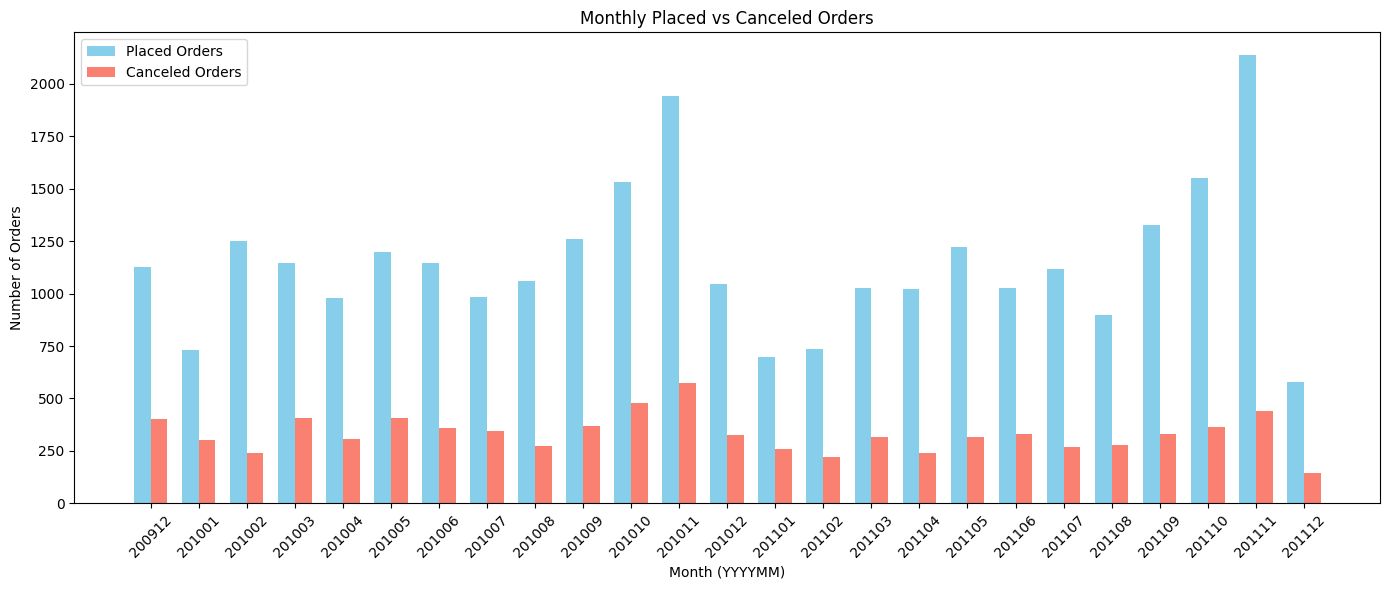

In [34]:
# Set positions for the bars
x = np.arange(len(monthly_orders['year_month']))
width = 0.35  # Width of the bars

plt.figure(figsize=(14,6))

# Plot placed orders
plt.bar(x - width/2, monthly_orders['placed_orders'], width, label='Placed Orders', color='skyblue')

# Plot canceled orders
plt.bar(x + width/2, monthly_orders['canceled_orders'], width, label='Canceled Orders', color='salmon')

# Add labels and title
plt.xticks(x, monthly_orders['year_month'], rotation=45)
plt.xlabel('Month (YYYYMM)')
plt.ylabel('Number of Orders')
plt.title('Monthly Placed vs Canceled Orders')
plt.legend()
plt.tight_layout()
plt.show()

# Monthly Sales

In [35]:
monthly_sales = pdf.groupby('year_month')['total_amount'].sum().reset_index()
monthly_sales.rename(columns={'total_amount': 'sales_amount'}, inplace=True)
monthly_sales

,year_month,sales_amount
0,200912,825685.760
1,201001,652708.502
2,201002,553713.306
3,201003,833570.131
4,201004,681528.992
5,201005,659858.860
6,201006,752270.140
7,201007,650712.940
8,201008,697274.910
9,201009,924333.011


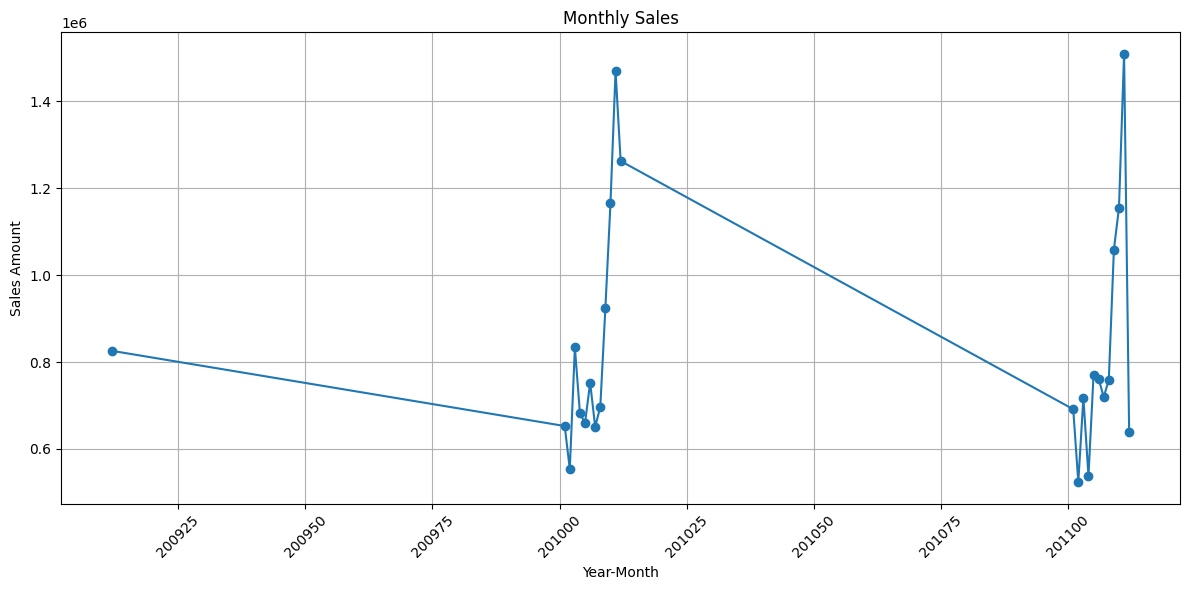

In [36]:
plt.figure(figsize=(12, 6))
plt.plot(monthly_sales['year_month'], monthly_sales['sales_amount'], marker='o', linestyle='-')
plt.title('Monthly Sales')
plt.xlabel('Year-Month')
plt.ylabel('Sales Amount')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

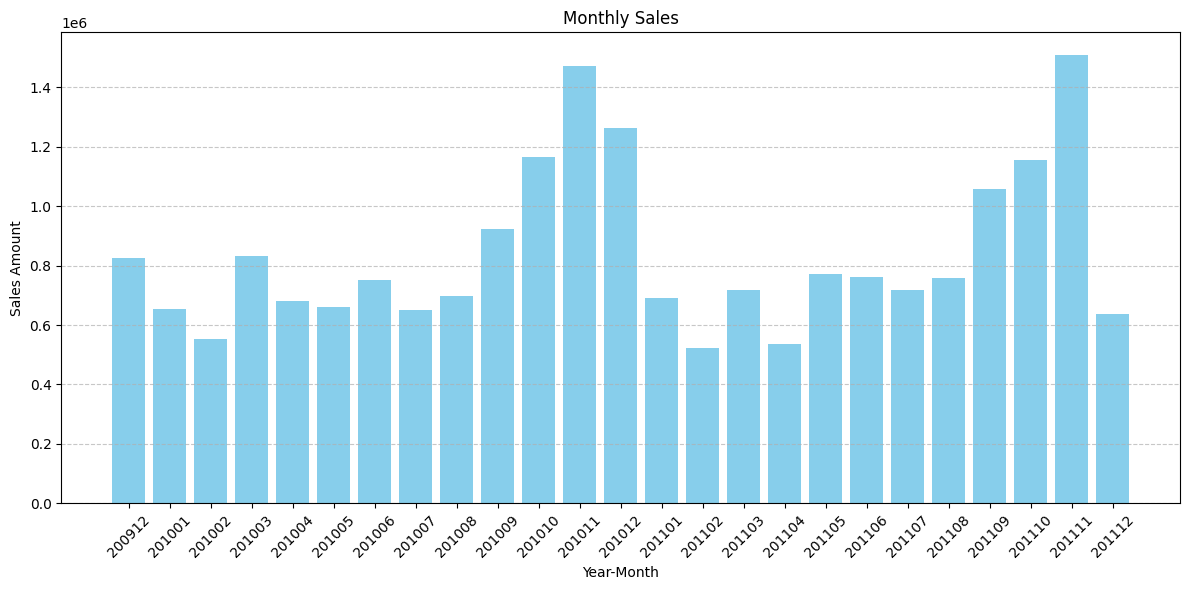

In [37]:
plt.figure(figsize=(12, 6))
plt.bar(monthly_sales['year_month'].astype(str), monthly_sales['sales_amount'], color='skyblue')
plt.title('Monthly Sales')
plt.xlabel('Year-Month')
plt.ylabel('Sales Amount')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [1]:
#different y-axis distribution

plt.figure(figsize=(12, 6))
plt.bar(monthly_sales['year_month'].astype(str), monthly_sales['sales_amount'], color='skyblue')
plt.title('Monthly Sales')
plt.xlabel('Year-Month')
plt.ylabel('Sales Amount')

# Format y-axis with commas
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

# Monthly Sales Growth


In [39]:
# Sort by year_month
monthly_sales = monthly_sales.sort_values('year_month')
#growth percentage
monthly_sales['sales_growth_pct'] = monthly_sales['sales_amount'].pct_change() * 100

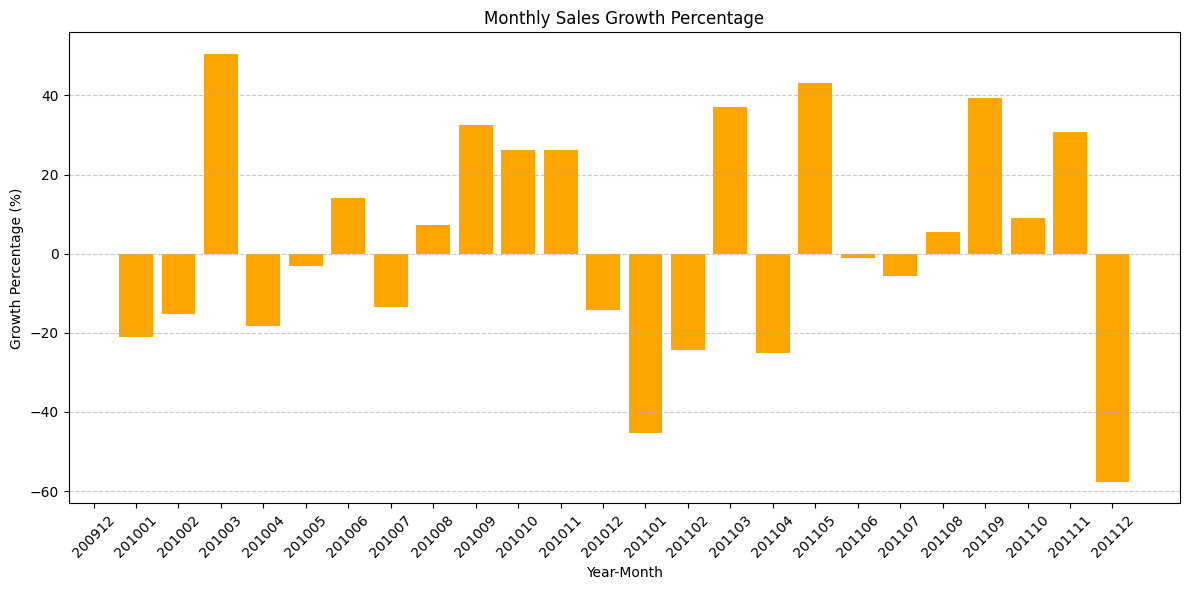

In [40]:
plt.figure(figsize=(12, 6))
plt.bar(monthly_sales['year_month'].astype(str), monthly_sales['sales_growth_pct'], color='orange')
plt.title('Monthly Sales Growth Percentage')
plt.xlabel('Year-Month')
plt.ylabel('Growth Percentage (%)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

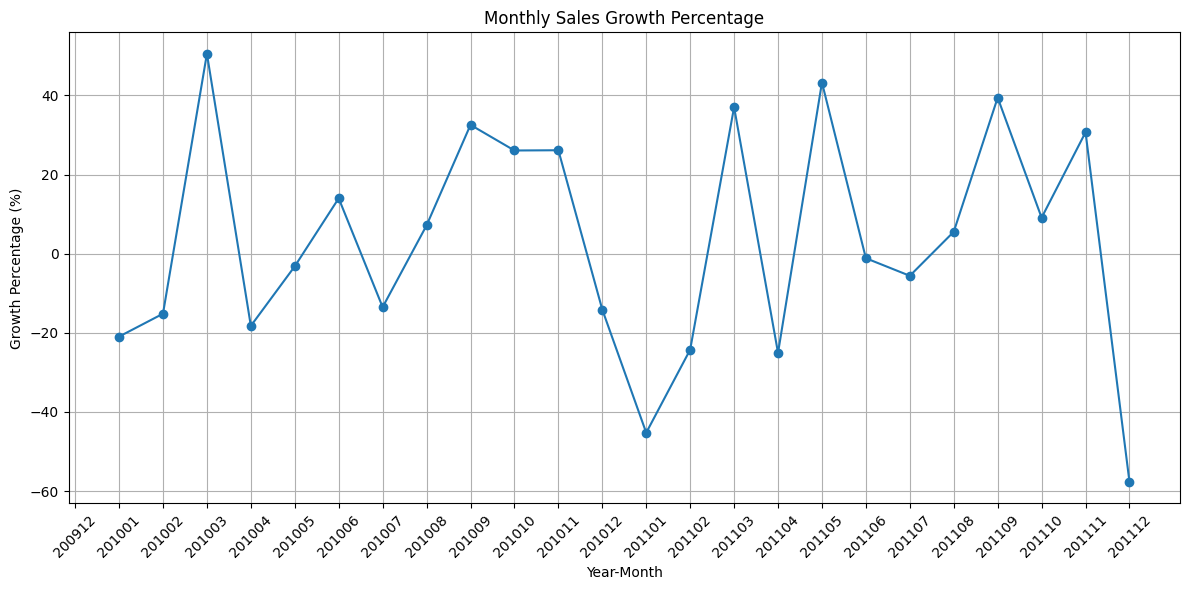

In [41]:
plt.figure(figsize=(12, 6))
plt.plot(monthly_sales['year_month'].astype(str), monthly_sales['sales_growth_pct'], marker='o', linestyle='-')
plt.title('Monthly Sales Growth Percentage')
plt.xlabel('Year-Month')
plt.ylabel('Growth Percentage (%)')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

# Monthly Active Users

In [42]:
#groupby year month unique customer id .sum()

In [43]:
all_invoices = df[['customer_id', 'year_month']]
all_invoices

,customer_id,year_month
0,13085.0,200912
1,13085.0,200912
2,13085.0,200912
3,13085.0,200912
4,13085.0,200912
...,...,...
1067366,12680.0,201112
1067367,12680.0,201112
1067368,12680.0,201112
1067369,12680.0,201112


In [44]:
active_users_month = all_invoices.groupby('year_month')['customer_id'].nunique().reset_index()
active_users_month.rename(columns={'customer_id': 'active_users'}, inplace=True)
active_users_month

,year_month,active_users
0,200912,1045
1,201001,786
2,201002,807
3,201003,1111
4,201004,998
5,201005,1062
6,201006,1095
7,201007,988
8,201008,964
9,201009,1202


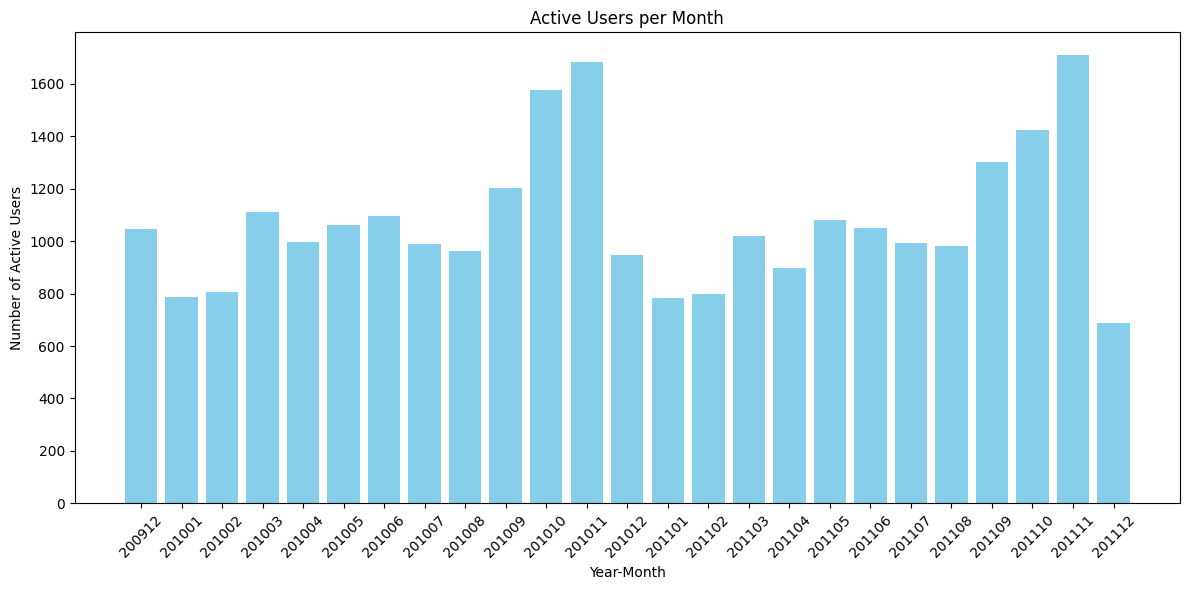

In [45]:
plt.figure(figsize=(12,6))
plt.bar(active_users_month['year_month'].astype(str), active_users_month['active_users'], color='skyblue')
plt.xlabel('Year-Month')
plt.ylabel('Number of Active Users')
plt.title('Active Users per Month')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# New and Existing Users



In [145]:
all_invoices = df.copy()

first_purchase = all_invoices.groupby('customer_id')['year_month'].min().reset_index()
first_purchase.rename(columns={'year_month': 'first_purchase_month'}, inplace=True)
first_purchase.head()


,customer_id,first_purchase_month
0,12346.0,200912
1,12347.0,201010
2,12348.0,201009
3,12349.0,200912
4,12350.0,201102


In [146]:
# Join first purchase month with transactional data
all_invoices = all_invoices.merge(first_purchase, on='customer_id', how='left')
all_invoices.head()

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country,total_amount,year_month,first_purchase_month
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,200912,200912.0
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,200912,200912.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,200912,200912.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,200912,200912.0
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,200912,200912.0


In [148]:
# Flag a user is new or existing in each transaction
all_invoices['user_type'] = all_invoices.apply(
    lambda row: 'new' if row['year_month'] == row['first_purchase_month'] else 'existing', axis=1
)

all_invoices.head()

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country,total_amount,year_month,first_purchase_month,user_type
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,200912,200912.0,new
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,200912,200912.0,new
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,200912,200912.0,new
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,200912,200912.0,new
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,200912,200912.0,new


In [130]:
users_month = all_invoices.groupby(['year_month', 'user_type'])['customer_id'].nunique().reset_index(name='number_of_customers')
users_month

,year_month,user_type,number_of_customers
0,200912,existing,0
1,200912,new,1045
2,201001,existing,392
3,201001,new,394
4,201002,existing,444
5,201002,new,363
6,201003,existing,675
7,201003,new,436
8,201004,existing,707
9,201004,new,291


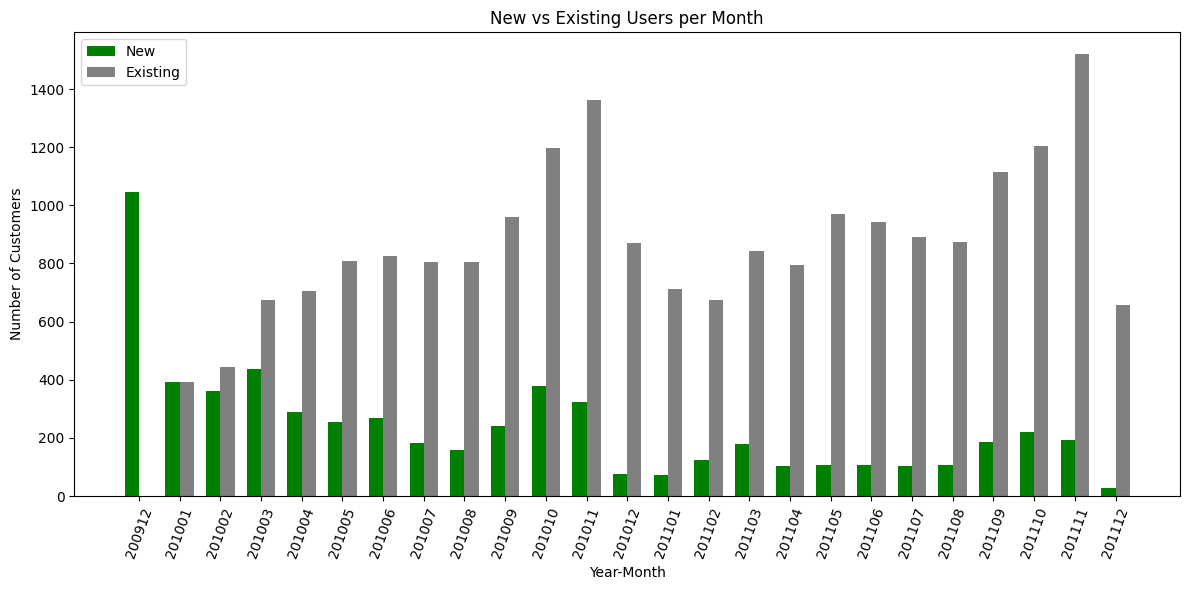

In [142]:
months = users_month['year_month'].unique()
x = np.arange(len(months))  # the label locations
width = 0.35  # width of the bars

# Get counts for each type
new_counts = users_month[users_month['user_type'] == 'new']['number_of_customers'].values
existing_counts = users_month[users_month['user_type'] == 'existing']['number_of_customers'].values

# Plot
fig, ax = plt.subplots(figsize=(12,6))
ax.bar(x - width/2, new_counts, width, label='New', color='green')
ax.bar(x + width/2, existing_counts, width, label='Existing', color='gray')

# Labels and title
ax.set_xlabel('Year-Month')
ax.set_ylabel('Number of Customers')
ax.set_title('New vs Existing Users per Month')
ax.set_xticks(x)
ax.set_xticklabels(months, rotation=70)
ax.legend()
plt.tight_layout()
plt.show()


## Finding RFM

RFM is a method used for analyzing customer value. It is commonly used in database marketing and direct marketing and has received particular attention in the retail and professional services industries. ([wikipedia](https://en.wikipedia.org/wiki/RFM_(market_research)))

Optional Reading: [Making Your Database Pay Off Using Recency Frequency and Monetary Analysis](http://www.dbmarketing.com/2010/03/making-your-database-pay-off-using-recency-frequency-and-monetary-analysis/)


RFM stands for three dimensions:

- Recency – How recently did the customer purchase?

- Frequency – How often do they purchase?

- Monetary Value – How much do they spend?

Note: To simplify the problem, let's keep all placed and canceled orders.


**Sample RFM table**

![](https://i.imgur.com/sXFIg6u.jpg)

In [51]:
df.head()

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country,total_amount,year_month
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,200912
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,200912
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,200912
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,200912
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,200912


In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 10 columns):
 #   Column        Non-Null Count    Dtype         
---  ------        --------------    -----         
 0   invoice_no    1067371 non-null  object        
 1   stock_code    1067371 non-null  object        
 2   description   1062989 non-null  object        
 3   quantity      1067371 non-null  int64         
 4   invoice_date  1067371 non-null  datetime64[ns]
 5   unit_price    1067371 non-null  float64       
 6   customer_id   824364 non-null   float64       
 7   country       1067371 non-null  object        
 8   total_amount  1067371 non-null  float64       
 9   year_month    1067371 non-null  int32         
dtypes: datetime64[ns](1), float64(3), int32(1), int64(1), object(4)
memory usage: 77.4+ MB


In [56]:
df['invoice_date'].min()

Timestamp('2009-12-01 07:45:00')

In [57]:
df['invoice_date'].max()

Timestamp('2011-12-09 12:50:00')

In [108]:
df.groupby('year_month')['invoice_no'].nunique().reset_index(name='invoice_count')

,year_month,invoice_count
0,200912,2330
1,201001,1633
2,201002,1969
3,201003,2367
4,201004,1892
5,201005,2418
6,201006,2216
7,201007,2017
8,201008,1877
9,201009,2375


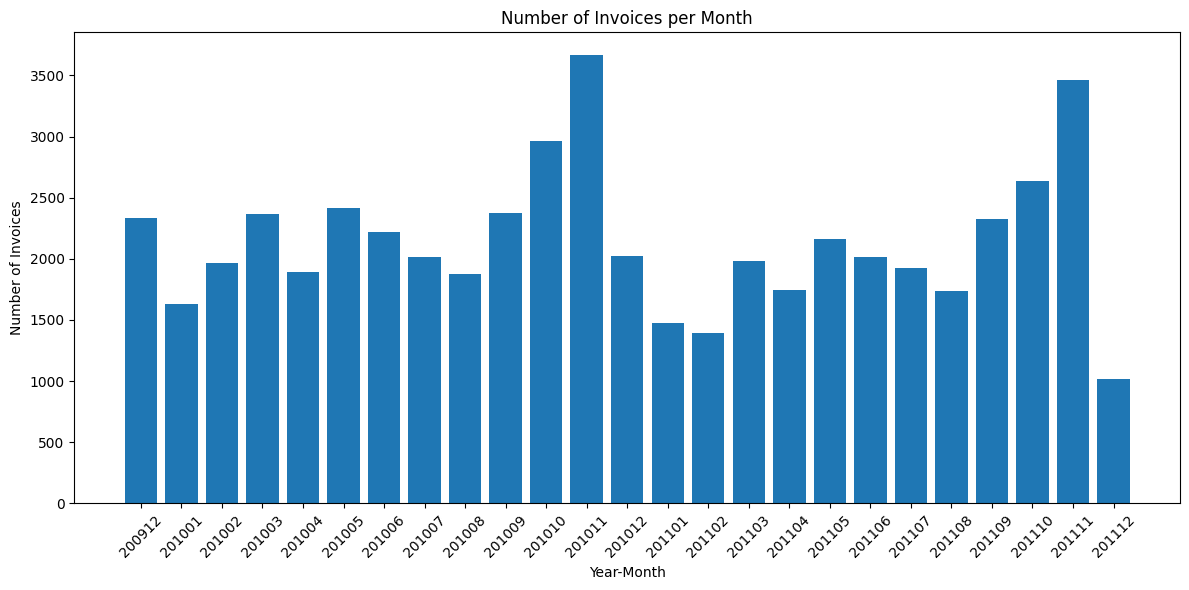

In [109]:
monthly_invoices = (
    df.groupby('year_month')['invoice_no'].nunique().reset_index(name='invoice_count')
)

plt.figure(figsize=(12, 6))
plt.bar(monthly_invoices['year_month'].astype(str),
        monthly_invoices['invoice_count'])

plt.xlabel('Year-Month')
plt.ylabel('Number of Invoices')
plt.title('Number of Invoices per Month')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [110]:
invoice_per_customer_month = (
    df.groupby(['customer_id', 'year_month'])['invoice_no'].nunique().reset_index(name='invoice_count')
)


In [2]:
#F in RFM
frequency = df.groupby('customer_id')['invoice_no'].nunique().reset_index(name='Frequency')
frequency

NameError: name 'df' is not defined

In [112]:
df.groupby(['customer_id','year_month'])['invoice_no'].nunique().reset_index(name='invoice_count')

,customer_id,year_month,invoice_count
0,12346.0,200912,5
1,12346.0,201001,5
2,12346.0,201003,1
3,12346.0,201006,2
4,12346.0,201010,2
...,...,...,...
26988,18287.0,201005,1
26989,18287.0,201009,2
26990,18287.0,201011,1
26991,18287.0,201105,1


In [113]:
pivot_table = invoice_per_customer_month.pivot(
    index='customer_id',
    columns='year_month',
    values='invoice_count'
).fillna(0)


In [114]:
pivot_table

year_month,200912,201001,201002,201003,201004,201005,201006,201007,201008,201009,...,201103,201104,201105,201106,201107,201108,201109,201110,201111,201112
customer_id,,,,,,,,,,,,,,,,,,,,,
12346.0,5.0,5.0,0.0,1.0,0.0,0.0,2.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12347.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0
12348.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
12349.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
12350.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18283.0,0.0,0.0,1.0,2.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,1.0,2.0,2.0,0.0,1.0,1.0,4.0,1.0
18284.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
18285.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [115]:
#checking the number of invoices as per customer which is the frequency in RFM
df.groupby('customer_id')['invoice_no'].nunique().reset_index(name='invoice_count')

,customer_id,invoice_count
0,12346.0,17
1,12347.0,8
2,12348.0,5
3,12349.0,5
4,12350.0,1
...,...,...
5937,18283.0,22
5938,18284.0,2
5939,18285.0,1
5940,18286.0,3


In [116]:
# Decided reference date is the last date in dataset +1
# find the last invoice date for each customer
last_invoice_per_customer = df.groupby('customer_id')['invoice_date'].max().reset_index()
last_invoice_per_customer.rename(columns={'invoice_date': 'LastPurchaseDate'}, inplace=True)

reference_date = df['invoice_date'].max() + pd.Timedelta(days=1)

# recency (days since last purchase)
last_invoice_per_customer['Recency'] = (reference_date - last_invoice_per_customer['LastPurchaseDate']).dt.days

last_invoice_per_customer.head()

,customer_id,LastPurchaseDate,Recency
0,12346.0,2011-01-18 10:17:00,326
1,12347.0,2011-12-07 15:52:00,2
2,12348.0,2011-09-25 13:13:00,75
3,12349.0,2011-11-21 09:51:00,19
4,12350.0,2011-02-02 16:01:00,310


In [117]:
monetary = df.groupby('customer_id')['total_amount'].sum().reset_index()
monetary.rename(columns={'total_amount': 'Monetary'}, inplace=True)
monetary.head()

,customer_id,Monetary
0,12346.0,-64.68
1,12347.0,5633.32
2,12348.0,2019.40
3,12349.0,4404.54
4,12350.0,334.40


In [118]:
# Merging RFM
rfm = last_invoice_per_customer.merge(frequency, on='customer_id')
rfm = rfm.merge(monetary, on='customer_id')
rfm_table = rfm[['customer_id', 'Recency', 'Frequency', 'Monetary']]
rfm_table.head()

,customer_id,Recency,Frequency,Monetary
0,12346.0,326,17,-64.68
1,12347.0,2,8,5633.32
2,12348.0,75,5,2019.40
3,12349.0,19,5,4404.54
4,12350.0,310,1,334.40


# RFM Segmentation

---
**Please remove this insturction cell after you are done with coding**
RFM segmentation categorizes your customers into different segments, according to their interactions with your website, which will allow you to subsequently approach these groups in the most effective way. In this article, we will show you how to make an RFM segmentation based on an RFM score combining all three RFM parameters together and allowing you to divide your customers into 11 different segments. 

- [RFM Segmentation business cases](https://docs.exponea.com/docs/rfm-segmentation-business-use)

- [RFM Segmentation Guide](https://docs.exponea.com/docs/rfm-segmentation-business-use)

As you can see, computing RFM segmentation requires extensive domain knowledge in marketing which is out of the scope in this project. In practice, you will work with BA/DA to figure out how to compute RFM segments. To simplify this project, a [sample RFM segmentation Notebook](https://github.com/jarviscanada/jarvis_data_eng_demo/blob/feature/data/python_data_wrangling/ipynb/customer-segmentation-with-rfm-score.ipynb) is provided. You are responsible to understand everything from that Notebook and then integrate it into yours. 

- Download the [sample notebook](https://github.com/jarviscanada/jarvis_data_eng_demo/blob/feature/data/python_data_wrangling/ipynb/customer-segmentation-with-rfm-score.ipynb) and import to your Jupyter Notebook or VSCode
- Run the notebook and understand all cells
- Read the remark section at the end of the notebook. You will need this information when writing the README file
- Integrate the RFM segmentation calculation into your notebook

---

In [119]:
# Recency: lower is better → reverse scoring
rfm_table['RecencyScore'] = pd.qcut(rfm_table['Recency'], 5, labels=[5,4,3,2,1])

# Frequency: higher is better
rfm_table['FrequencyScore'] = pd.qcut(rfm_table['Frequency'].rank(method="first"), 5, labels=[1,2,3,4,5])

# Monetary: higher is better
rfm_table['MonetaryScore'] = pd.qcut(rfm_table['Monetary'], 5, labels=[1,2,3,4,5])


rfm_table['RFM_SCORE'] = (rfm_table['RecencyScore'].astype(str) +
                          rfm_table['FrequencyScore'].astype(str) +
                          rfm_table['MonetaryScore'].astype(str))
rfm_table.head()

,customer_id,Recency,Frequency,Monetary,RecencyScore,FrequencyScore,MonetaryScore,RFM_SCORE
0,12346.0,326,17,-64.68,2,5,1,251
1,12347.0,2,8,5633.32,5,4,5,545
2,12348.0,75,5,2019.40,3,3,4,334
3,12349.0,19,5,4404.54,4,3,5,435
4,12350.0,310,1,334.40,2,1,2,212


In [122]:
seg_map = {
    r'[1-2][1-2]': 'Hibernating',
    r'[1-2][3-4]': 'At Risk',
    r'[1-2]5': 'Can\'t Lose',
    r'3[1-2]': 'About to Sleep',
    r'33': 'Need Attention',
    r'[3-4][4-5]': 'Loyal Customers',
    r'41': 'Promising',
    r'51': 'New Customers',
    r'[4-5][2-3]': 'Potential Loyalists',
    r'5[4-5]': 'Champions'
}

# combined string of RecencyScore and FrequencyScore
rfm_table['Segment'] = (rfm_table['RecencyScore'].astype(str) +
                        rfm_table['FrequencyScore'].astype(str))

rfm_table['Segment'] = rfm_table['Segment'].replace(seg_map, regex=True)
rfm_table.head()

,customer_id,Recency,Frequency,Monetary,RecencyScore,FrequencyScore,MonetaryScore,RFM_SCORE,Segment
0,12346.0,326,17,-64.68,2,5,1,251,Can't Lose
1,12347.0,2,8,5633.32,5,4,5,545,Champions
2,12348.0,75,5,2019.40,3,3,4,334,Need Attention
3,12349.0,19,5,4404.54,4,3,5,435,Potential Loyalists
4,12350.0,310,1,334.40,2,1,2,212,Hibernating
